# SQLDatabase를 이용한 Tool 생성
- SQLDatabase 도구를 사용하면 데이터베이스와 자연어로 상호작용할 수 있습니다. 초보자도 쉽게 따라할 수 있는 예제를 만들어보겠습니다.


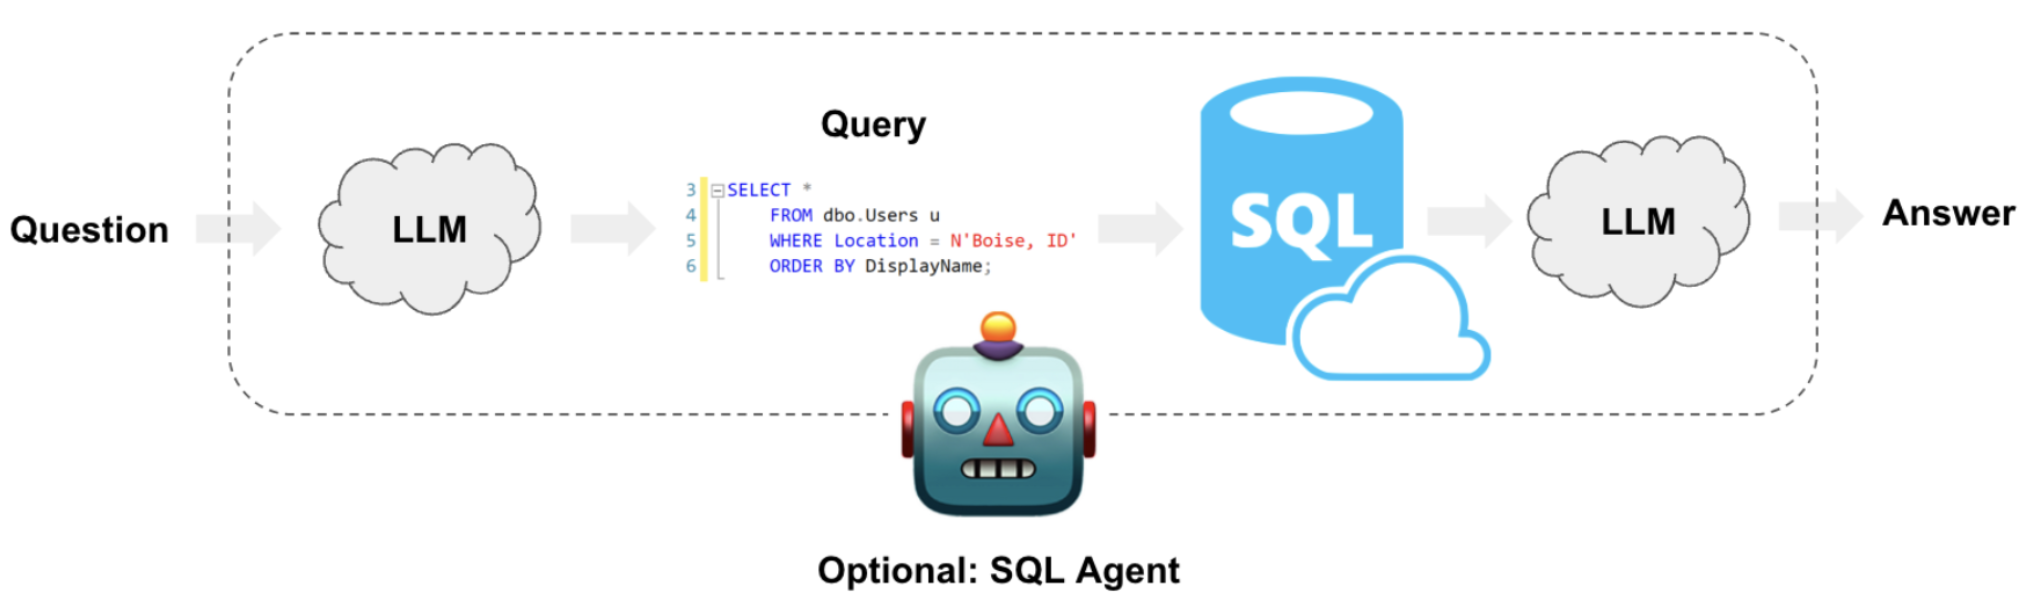


### 핵심 포인트:
1. **자연어 쿼리**: SQL을 몰라도 자연어로 데이터베이스 조회 가능
2. **안전한 접근**: 도구를 통해 안전하게 데이터베이스에 접근
3. **복합 분석**: 여러 테이블을 조인하여 복잡한 분석 수행
4. **LCEL 통합**: 다른 도구들과 연계하여 종합적인 데이터 분석

### 주의사항:
- 실제 운영 데이터베이스 사용시 읽기 전용 권한 권장
- 민감한 데이터는 별도 보안 조치 필요
- 대용량 데이터베이스의 경우 쿼리 최적화 고려


## QuerySQLDatabaseTool vs SQLDatabaseToolkit

| 구분    | QuerySQLDatabaseTool | SQLDatabaseToolkit           |
| ----- | -------------------- | ---------------------------- |
| 역할    | SQL 실행기 (단일 기능)      | SQL 관련 도구 모음 (복합 기능)         |
| 입력    | 완성된 SQL 쿼리           | 자연어 질문 또는 에이전트 액션            |
| 내부 기능 | 단순 실행만 함             | 테이블 정보, 스키마 확인, 쿼리 검증, 실행 등  |
| 복잡도   | 간단함                  | 조금 더 설정이 필요함                 |
| 사용 목적 | 이미 SQL 쿼리를 알고 있을 때   | LLM이 SQL을 자동으로 작성하고 실행하게 할 때 |
| 구성 요소 | 단일 도구                | 여러 도구(4~5개)로 구성됨             |


# 예시

## [1단계: 타이타닉 데이터 로드](https://www.kaggle.com/competitions/titanic)
> 타이타닉(Titanic) 데이터는 데이터 분석과 머신러닝 입문용으로 가장 많이 사용되는 대표적인 예제 데이터셋이에요.    
> 특히, `탑승객이 생존했는가?`를 예측하는 문제로 자주 쓰입니다.

| 컬럼명             | 의미                                | 예시                        |
| --------------- | --------------------------------- | ------------------------- |
| **PassengerId** | 승객 ID (고유 번호)                     | 1, 2, 3, ...              |
| **Survived**    | 생존 여부 (0 = 사망, 1 = 생존)            | 0                         |
| **Pclass**      | 객실 등급 (1 = 1등석, 2 = 2등석, 3 = 3등석) | 3                         |
| **Name**        | 이름                                | “Braund, Mr. Owen Harris” |
| **Sex**         | 성별                                | male / female             |
| **Age**         | 나이                                | 22                        |
| **SibSp**       | 함께 탑승한 형제자매/배우자 수                 | 1                         |
| **Parch**       | 함께 탑승한 부모/자녀 수                    | 0                         |
| **Ticket**      | 티켓 번호                             | A/5 21171                 |
| **Fare**        | 운임 요금                             | 7.25                      |
| **Cabin**       | 객실 번호                             | C85                       |
| **Embarked**    | 승선 항구 (C=셰르부르, Q=퀸스타운, S=사우샘프턴)   | S                         |


In [26]:
import pandas as pd

DATA_PATH = "./data/"
df = pd.read_csv(DATA_PATH+"Titanic.csv")

print(f"(전체 데이터 수, 전체 컬럼 수)-> {df.shape}")
print(f"전체 컬럼명: {df.columns.tolist()}")

(전체 데이터 수, 전체 컬럼 수)-> (891, 12)
전체 컬럼명: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [27]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2단계: Create Engine

In [28]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///titanic.db")

## 3단계: titanic.db 파일 생성 및 데이터 추가

In [29]:
df.to_sql("titanic", engine, index=False)

891

## 4단계: SQLDatabase 생성

In [30]:
from langchain_community.utilities.sql_database import SQLDatabase

db = SQLDatabase(engine=engine)

print(f"데이터베이스 종류: {db.dialect}")
print(f"테이블 리스트: {db.get_usable_table_names()}")

데이터베이스 종류: sqlite
테이블 리스트: ['titanic']


In [31]:
result = db.run("SELECT * FROM titanic WHERE Age < 10;")

In [32]:
result[:50]

"[(8, 0, 3, 'Palsson, Master. Gosta Leonard', 'male"

> ast.literal_eval()는 문자열 형태의 파이썬 리터럴(literal)을 "안전하게" 실제 파이썬 객체로 변환하는 함수 입니다.

In [33]:
import ast

lst_result = ast.literal_eval(result)
print(f"조회된 데이터 수: {len(lst_result)}")
print(f"조회된 데이터 중 첫번째 데이터: {lst_result[0]}")


조회된 데이터 수: 62
조회된 데이터 중 첫번째 데이터: (8, 0, 3, 'Palsson, Master. Gosta Leonard', 'male', 2.0, 3, 1, '349909', 21.075, None, 'S')


## 5단계: LLM 생성

In [34]:
from dotenv import load_dotenv

# 환경변수 로드
load_dotenv()

True

In [35]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

## 6단계: SQLDatabaseToolkit 생성

In [36]:
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit

toolkit = SQLDatabaseToolkit(db=db, llm=llm)

In [37]:
tools = toolkit.get_tools()

for tool in tools:
    print("=" * 50)
    print(f"Tool 이름: {tool.name}")
    print(f"Tool 설명: {tool.description}")
    print(f"Tool 인풋 파라미터: {tool.args}")
    print(f"Tool return_direct: {tool.return_direct}")

Tool 이름: sql_db_query
Tool 설명: Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.
Tool 인풋 파라미터: {'query': {'description': 'A detailed and correct SQL query.', 'title': 'Query', 'type': 'string'}}
Tool return_direct: False
Tool 이름: sql_db_schema
Tool 설명: Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3
Tool 인풋 파라미터: {'table_names': {'description': "A comma-separated list of the table names for which to return the schema. Example input: 'table1, table2, table3'", 'title': 'Table Names', 'type': 'string'}}
Tool retu

| 도구 이름                      | 입력 (Input)                               | 출력 (Output)                                     | 주요 기능                       | 사용 시기 / 목적                     |
| -------------------------- | ---------------------------------------- | ----------------------------------------------- | --------------------------- | ------------------------------ |
| **`sql_db_list_tables`**   | 빈 문자열 (`""`)                             | 데이터베이스 안의 테이블 목록 (예: `users, orders, products`) | DB 안에 어떤 테이블이 있는지 조회        | 데이터베이스 구조를 처음 탐색할 때 사용         |
| **`sql_db_schema`**        | 테이블 이름 목록 (쉼표로 구분, 예: `"users, orders"`) | 각 테이블의 **컬럼 구조**와 **샘플 데이터**                    | 테이블 구조(필드명, 자료형, 예시 데이터) 확인 | 쿼리 작성 전, 어떤 필드가 있는지 확인할 때      |
| **`sql_db_query_checker`** | SQL 쿼리문 (예: `"SELECT name FROM users;"`) | 쿼리가 유효한지 여부 (문법 오류나 잘못된 필드 감지)                  | 쿼리 실행 전에 오류 여부를 미리 점검       | `sql_db_query` 실행 전에 반드시 사용 권장 |
| **`sql_db_query`**         | 올바른 SQL 쿼리문                              | 쿼리 결과 (예: 표 형태의 데이터)                            | 실제로 SQL을 실행하고 결과 반환         | 최종적으로 데이터 추출, 분석할 때 사용         |


## [7단계: create_agent 생성](https://docs.langchain.com/oss/python/langchain/sql-agent)
> system_prompt는 LangChain SQL Agent가 데이터베이스와 대화할 때 지켜야 할 "행동 지침서(역할 설명문)"입니다.   
> 즉, AI에게 SQL을 어떻게 생성하고 실행할지 가르치는 규칙집입니다.

In [38]:
system_prompt = """
You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run,
then look at the results of the query and return the answer. Unless the user
specifies a specific number of examples they wish to obtain, always limit your
query to at most {top_k} results.

You can order the results by a relevant column to return the most interesting
examples in the database. Never query for all the columns from a specific table,
only ask for the relevant columns given the question.

You MUST double check your query before executing it. If you get an error while
executing a query, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the
database.

To start you should ALWAYS look at the tables in the database to see what you
can query. Do NOT skip this step.

Then you should query the schema of the most relevant tables.
""".format(
    dialect=db.dialect, # 데이터베이스 종류(sqlite3)
    top_k=5,            # 최대 결과 수
)

In [39]:
from langchain.agents import create_agent

agent = create_agent(
    llm,
    tools,
    system_prompt=system_prompt,
)

### 테스트 

> 콜백 핸들러 사용: StdOutCallbackHandler를 사용하면 에이전트의 실행 과정을 콘솔에 출력할 수 있습니다.

In [40]:
from langchain_core.callbacks import StdOutCallbackHandler

callbacks = [StdOutCallbackHandler()]

In [41]:
from langchain_core.messages import HumanMessage

user_input = "평균 생존자들의 나이는?"
result = agent.invoke(
    {"messages": HumanMessage(content=user_input)},
    config={"callbacks": callbacks}
)



> Entering new LangGraph chain...


> Entering new model chain...


> Entering new model_to_tools chain...

> Finished chain.

> Finished chain.


> Entering new tools chain...
content='titanic' name='sql_db_list_tables' tool_call_id='call_dI9KzVl4qpyjo2Xe2elTZlak'

> Entering new tools_to_model chain...

> Finished chain.

> Finished chain.


> Entering new model chain...


> Entering new model_to_tools chain...

> Finished chain.

> Finished chain.


> Entering new tools chain...
content='\nCREATE TABLE titanic (\n\t"PassengerId" BIGINT, \n\t"Survived" BIGINT, \n\t"Pclass" BIGINT, \n\t"Name" TEXT, \n\t"Sex" TEXT, \n\t"Age" FLOAT, \n\t"SibSp" BIGINT, \n\t"Parch" BIGINT, \n\t"Ticket" TEXT, \n\t"Fare" FLOAT, \n\t"Cabin" TEXT, \n\t"Embarked" TEXT\n)\n\n/*\n3 rows from titanic table:\nPassengerId\tSurvived\tPclass\tName\tSex\tAge\tSibSp\tParch\tTicket\tFare\tCabin\tEmbarked\n1\t0\t3\tBraund, Mr. Owen Harris\tmale\t22.0\t1\t0\tA/5 21171\t7.25\tNone\tS\n2\t1\t1\tCumings, Mrs. John Bradley

In [42]:
print(result['messages'][-1].content)

생존자(Survived=1)의 평균 나이는 약 28.34세입니다. (정확값: 28.343689655172415)


## [Langsmith에서 확인하기](https://smith.langchain.com/)

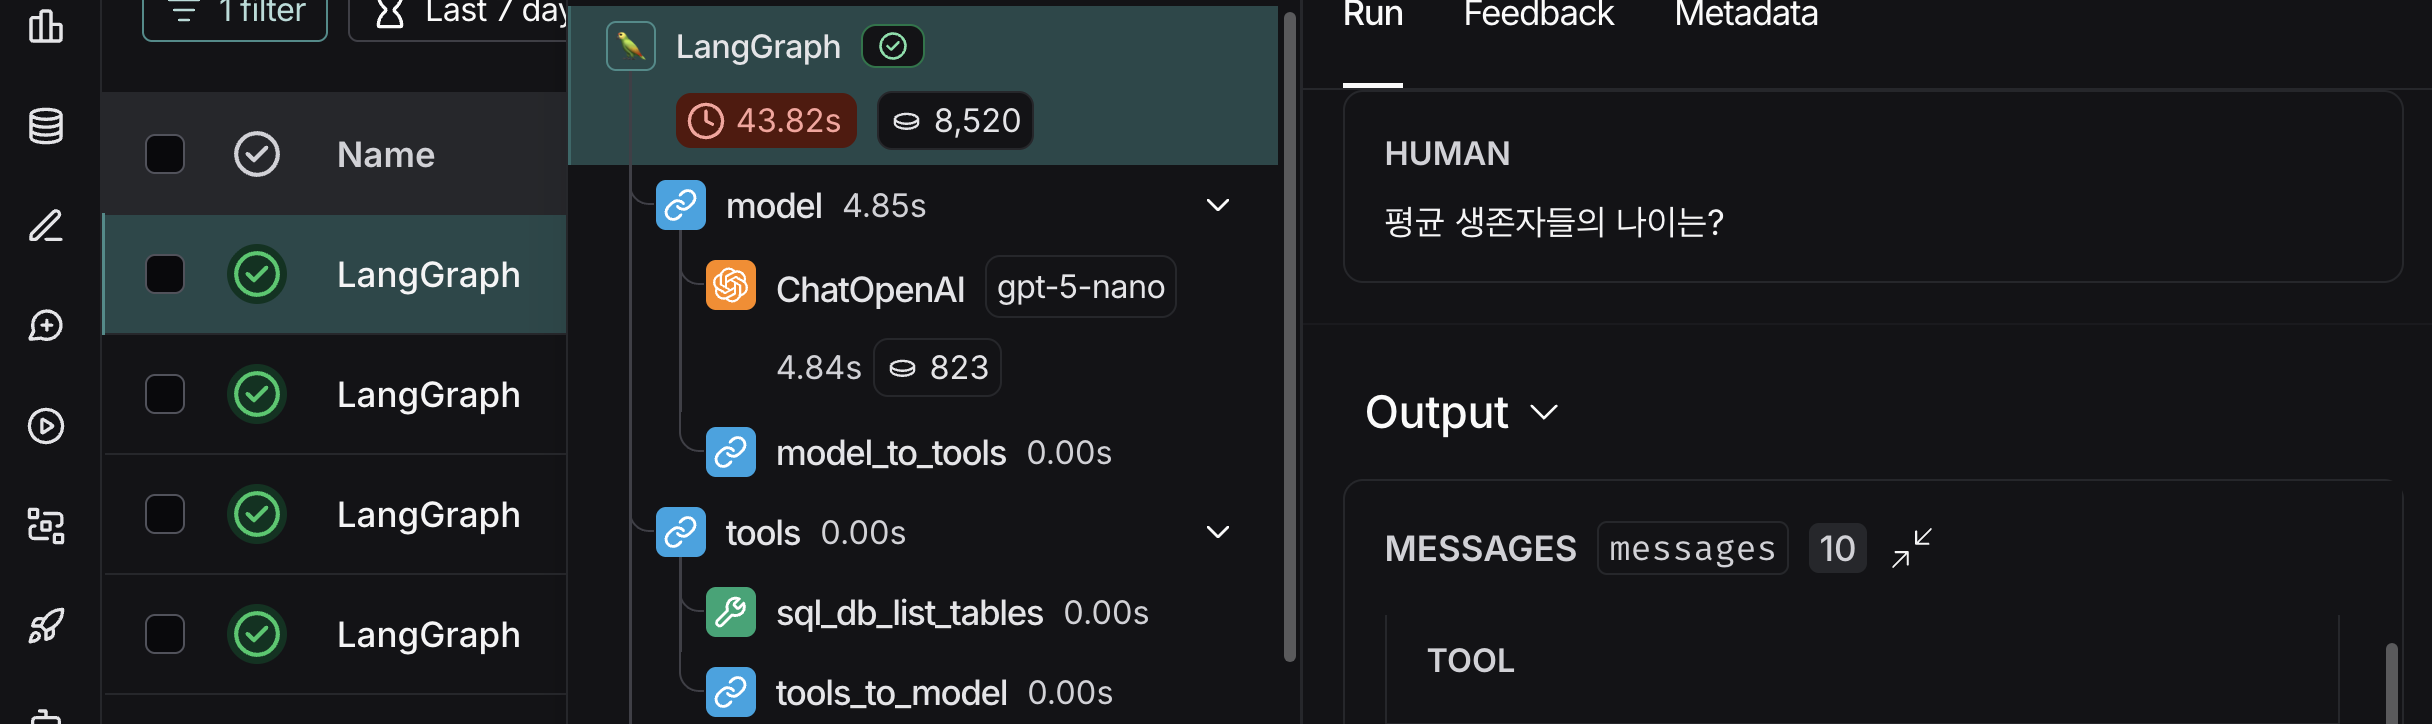